In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Vector que prepresenta 4 diferentes casas con sus respestivas areas en m2 (primera posicion)
# y numero de habitaciones (segunda posicion)
X = np.array([[80,3],[120,3],[100,2],[150,4]])

# costo de la casas en Miles de USD

y = np.array([310,390,325,530])


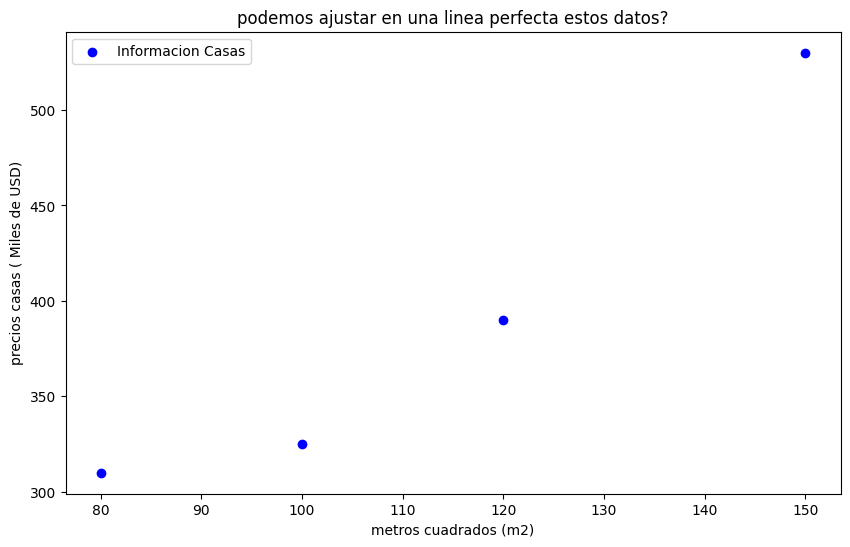

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],y, color ='blue', label ='Informacion Casas')
plt.xlabel('metros cuadrados (m2)')
plt.ylabel('precios casas ( Miles de USD)')
plt.title('podemos ajustar en una linea perfecta estos datos?')
plt.legend()
plt.show()

In [ ]:
# AGREGA COLUMNA DE UNOS en la primera columna de la matriz x, PARA EVITAR QUE PASE POR EL ORIGEN 0,0

X_bias = np.c_[np.ones((4,1)),X]
print(X_bias)

[[  1.  80.   3.]
 [  1. 120.   3.]
 [  1. 100.   2.]
 [  1. 150.   4.]]


In [ ]:
A = X_bias.T @ X_bias
b = X_bias.T @ y
print(A)
print(b)

[[4.00e+00 4.50e+02 1.20e+01]
 [4.50e+02 5.33e+04 1.40e+03]
 [1.20e+01 1.40e+03 3.80e+01]]
[  1555. 183600.   4870.]


In [ ]:
de_A =np.linalg.det(A)
print(de_A)

A_rango = np.linalg.matrix_rank(A)
print(A_rango)

11400.000000000038
3


In [ ]:
A_inversa = np.linalg.inv(A)
print(A_inversa)

[[ 5.73684211e+00 -2.63157895e-02 -8.42105263e-01]
 [-2.63157895e-02  7.01754386e-04 -1.75438596e-02]
 [-8.42105263e-01 -1.75438596e-02  9.38596491e-01]]


In [ ]:
theta_con_inversa = A_inversa @ b
print(theta_con_inversa)

[-11.84210526   2.48245614  40.43859649]


In [ ]:
theta_con_solve = np.linalg.solve(A,b)
print(theta_con_solve)

[-11.84210526   2.48245614  40.43859649]


In [ ]:
theta = theta_con_solve
predicciones = X_bias @ theta

print(f"precios reales: {y}")
print(f"precios predichos: {np.round(predicciones,1)}")

precios reales: [310 390 325 530]
precios predichos: [308.1 407.4 317.3 522.3]


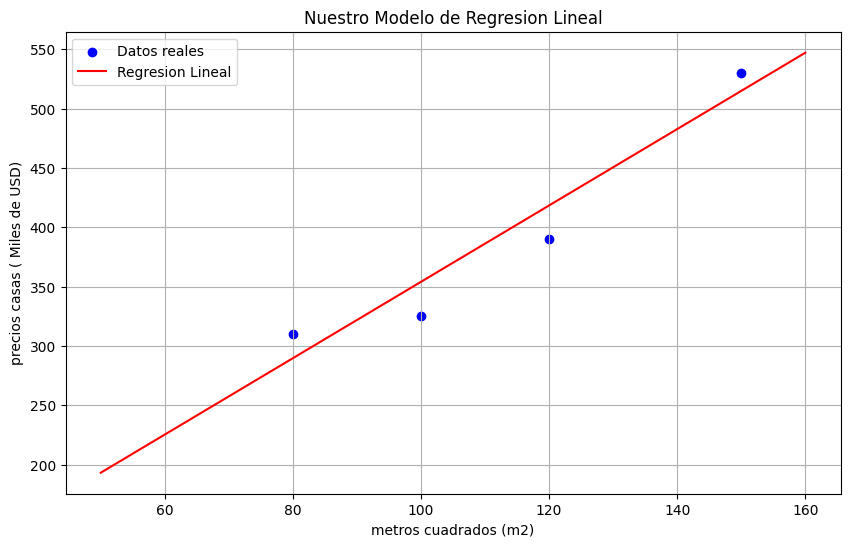

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],y, color ='blue', label ='Datos reales')
X_linea = np.array([[50], [160]])
X_linea_bias = np.c_[np.ones((2,1)),X_linea, np.array([[2],[4]])]
y_linea = X_linea_bias @ theta
plt.plot(X_linea, y_linea, color ='red', label ='Regresion Lineal')

plt.xlabel('metros cuadrados (m2)')
plt.ylabel('precios casas ( Miles de USD)')
plt.title('Nuestro Modelo de Regresion Lineal')
plt.grid("True")
plt.legend()
plt.show()

In [ ]:
pies_cuadrados = X[:,0]*10.764
X_enfermo = np.c_[X, pies_cuadrados]
X_enfermo_bias = np.c_[np.ones((4,1)),X_enfermo]
print(X_enfermo_bias)


[[1.00000e+00 8.00000e+01 3.00000e+00 8.61120e+02]
 [1.00000e+00 1.20000e+02 3.00000e+00 1.29168e+03]
 [1.00000e+00 1.00000e+02 2.00000e+00 1.07640e+03]
 [1.00000e+00 1.50000e+02 4.00000e+00 1.61460e+03]]


In [ ]:
A_enfermo = X_enfermo_bias.T @ X_enfermo_bias
b = X_enfermo_bias.T @ y
print(A_enfermo)
print(b)

[[4.000000e+00 4.500000e+02 1.200000e+01 4.843800e+03]
 [4.500000e+02 5.330000e+04 1.400000e+03 5.737212e+05]
 [1.200000e+01 1.400000e+03 3.800000e+01 1.506960e+04]
 [4.843800e+03 5.737212e+05 1.506960e+04 6.175535e+06]]
[1.5550000e+03 1.8360000e+05 4.8700000e+03 1.9762704e+06]


In [ ]:
det_A_enfermo = np.linalg.det(A_enfermo)
print(det_A_enfermo)
print(np.linalg.matrix_rank(A_enfermo))

0.0
3


In [ ]:
# Error porque la matriz es singular

theta = np.linalg.solve(A_enfermo,b)
print(theta)

LinAlgError: Singular matrix

In [ ]:
# Error porque la matriz es singular
theta = np.linalg.solve(A_enfermo,b)
print(theta)

LinAlgError: Singular matrix

In [ ]:
A_pseudo_inv = np.linalg.pinv(A_enfermo)
print(A_pseudo_inv)

[[ 5.73684211e+00 -2.25183615e-04 -8.42105263e-01 -2.42387643e-03]
 [-2.25185573e-04  5.13838303e-08 -1.50122082e-04  5.53095549e-07]
 [-8.42105263e-01 -1.50122410e-04  9.38596491e-01 -1.61591762e-03]
 [-2.42387624e-03  5.53094813e-07 -1.61591765e-03  5.95351256e-06]]


In [ ]:
theta = A_pseudo_inv @ b
print(theta)

[-1.18421053e+01  2.12423269e-02  4.04385965e+01  2.28652342e-01]


In [ ]:
predicciones = X_enfermo_bias @ theta
print(np.round(predicciones,1))
print(y)

[308.1 407.4 317.3 522.3]
[310 390 325 530]


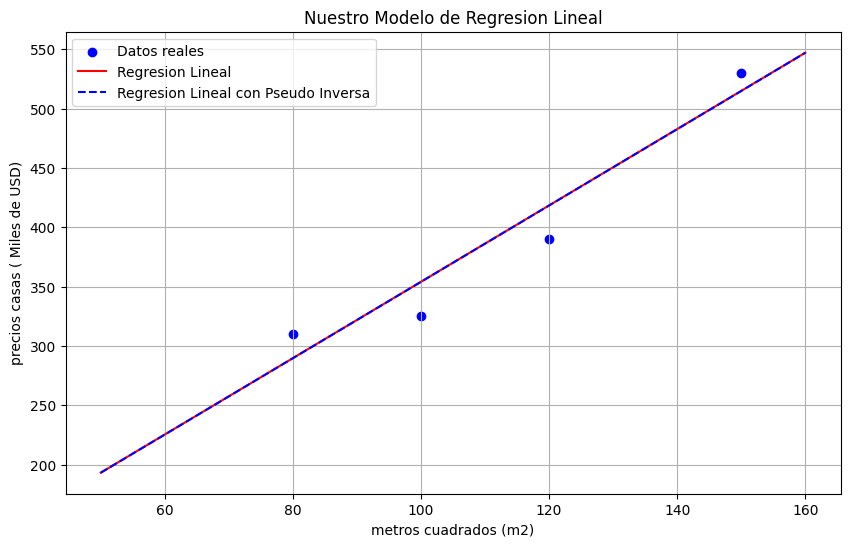

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],y, color ='blue', label ='Datos reales')
X_linea = np.array([[50], [160]])
X_linea_bias = np.c_[np.ones((2,1)),X_linea, np.array([[2],[4]])]

plt.plot(X_linea, y_linea, color ='red', label ='Regresion Lineal')

X_linea2 = np.array([[50], [160]])
X_linea_bias2 = np.c_[np.ones((2,1)),X_linea2, np.array([[2,538],[4,1722]])]
y_linea2 = X_linea_bias2 @ theta

plt.plot(X_linea, y_linea2, 'b--', label ='Regresion Lineal con Pseudo Inversa')

plt.xlabel('metros cuadrados (m2)')
plt.ylabel('precios casas ( Miles de USD)')
plt.title('Nuestro Modelo de Regresion Lineal')
plt.grid("True")
plt.legend()
plt.show()